In [1]:
%load_ext autoreload
%autoreload 2

import gurobipy as gp
from gurobipy import GRB

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from first_model import Instance, Solution, Model
from utils import *

## Pas de travailleur qualifié pour finaliser le job 1 
### la difference de niveau entre les travaileurs et la tâche est trop grande (>1)

In [18]:
print("======== INSTANCE ========")
res = read_file("../data/data_resale_price_simple.test")
instance = Instance()
instance.from_dictionary(res)

print(instance.sum_of_job_alone())
print(instance)
print("Les travailleurs qualifiés pour chaque tâche sont : ")
instance.qualified_workers_for_task(verbose=True)
print("Les jobs faisable sont : ", instance.feseable_jobs())

======== INSTANCE ========
5.0

 ===== Start of Instance: =====
Number of jobs: 2
Number of professions: 2
Number of tasks per profession: [1. 1.]
Max number of operations per Jobs: 2
Total number of tasks: 2
Total number of workers: 2
Task to profession mapping:
{0: 0, 1: 1}
Worker levels: shape=(2, 2)
 [[2. 1.]
 [1. 1.]]
Job difficulties: shape= (2,)
[3. 3.]
Job resale prices: shape= (2,)
[20. 20.]
Task difficulties: shape= (2,)
[1 3]
Task processing times: shape= (2, 3)
[[ 1.  2. -1.]
 [ 2. 10.  1.]]
Jobs structure: len= 2
Job 0 : 	O_(0,0) = 0 	O_(0,1) = 1 
Job 1 : 	O_(1,0) = 0 	O_(1,1) = 0 

Precedence constraints: shape= (2, 2, 2)
[[[0. 1.]
  [0. 0.]]

 [[0. 1.]
  [0. 0.]]]

 ===== End of Instance: =====

Les travailleurs qualifiés pour chaque tâche sont : 
J1:  (1,1): [1, 2] 	 (1,2): [] 	

J2:  (2,1): [1, 2] 	 (2,2): [1, 2] 	

Les jobs faisable sont :  [1]


- Aucun worker a le niveau pour $O_{12}$ -> difficulté de 3
- Sur cette opération $w_1$ et  $w_2$ sont de level 1
- Différence de niveau trop grande (>1)
- Donc $J_1$ ne peut etre fait

In [19]:
print("======== MODEL ========")
model = Model(instance)

======== MODEL ========
Born sup makespan: 12


In [20]:
print("======== CONFIG ========")
constraints_config = {"constrained_makespan": True,
                      "job_with_no_skills": True }

# de base : 
# - worker de base 
# - pas le droit de fair une opération sans level requis


======== CONFIG ========


In [21]:
print("======== SOLVE ========")
s = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[2, 1, 0], constraints_config=constraints_config, verbose=False)

======== SOLVE ========
job with no skills activated
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 20.0


======== RESULTS ========


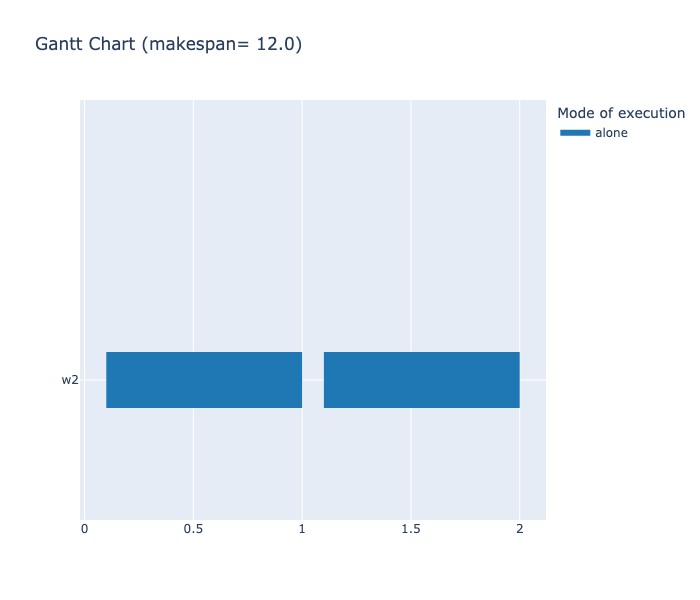

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w2,0.1,1.0,1.0,1.0,"(2,1)",J2,alone,1.0,1,0.0,0.0
1,w2,1.1,2.0,2.0,1.0,"(2,2)",J2,alone,1.0,1,0.0,0.0


In [22]:
print("======== RESULTS ========")
df = gantt_chart(s, instance, render="notebook", separate_little=True, color=3)
df

In [25]:
print("df ok ?:", check_df(df))
print("Tous les jobs sont complétés ?:", s.all_jobs_completed())
print("Quels jobs sont complétés ?:", s.which_jobs_are_completed())
print("Penalty makespan:", s.penalty_makespan)
# print(s)

df ok ?: True
Tous les jobs sont complétés ?: False
Quels jobs sont complétés ?: [1]
Penalty makespan: 0.0


======= VISUALIZATION ========
Gains de niveaux de chaque travailleur pour chaque profession :
[[0. 0.]
 [0. 0.]]
Gains de niveaux pour chaque travailleur :
[0. 0.]
Gains de niveaux pour chaque profession :
[0. 0.]


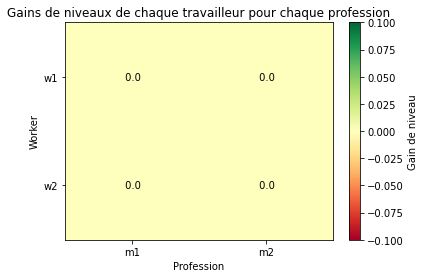

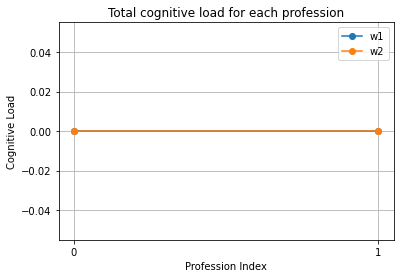

cognitive_load_total_per_worker=
[0. 0.]


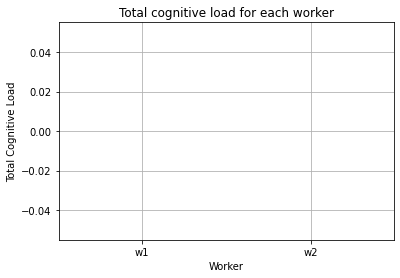

In [14]:
print("======= VISUALIZATION ========")
resume_levels_workers(s, instance, verbose=True)
plot_cognitive_load_total(s, instance)
bars_cognitive_load_total(s, instance, verbose=True)

## Pas de travailleur qualifié pour finaliser le job 1 
### la difference de niveau entre les travaileurs et la tâche est raisonnable (<=1)

In [36]:
from copy import deepcopy
instance_2 = deepcopy(instance)
print(instance.levels_workers)

[[2. 1.]
 [1. 1.]]


In [37]:
instance_2.levels_workers[0][1] += 1 # Le level du worker 1 pour le corps de métier 2 passe de 1 à 2

In [38]:
print(instance_2.levels_workers)

[[2. 2.]
 [1. 1.]]


- Le worker 1 est en mesure d'executer le job 1 si on autorise les worker avec niveau de difference <=1 au niveau de difficulté de la tache

In [39]:
print("======== SOLVE ========")
model_2 = Model(instance_2)
s_2 = model_2.solve(objective="lexicographic", weight=[0, 0, 0], priority=[2, 1, 0], constraints_config=constraints_config, verbose=False)

======== SOLVE ========
Born sup makespan: 12
job with no skills activated
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 40.0


======== RESULTS ========


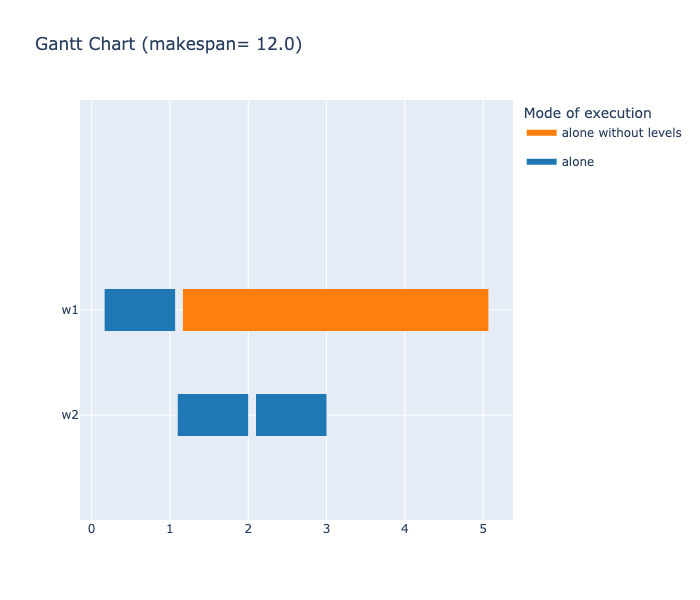

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w1,0.166667,1.066667,1.066667,1.0,"(1,1)",J1,alone,2.0,1,0.0,0.0
1,w1,1.166667,5.066667,5.066667,4.0,"(1,2)",J1,alone without levels,2.0,3,1.0,1.0
2,w2,1.100000,2.000000,2.000000,1.0,"(2,1)",J2,alone,1.0,1,0.0,0.0
3,w2,2.100000,3.000000,3.000000,1.0,"(2,2)",J2,alone,1.0,1,0.0,0.0


In [40]:
print("======== RESULTS ========")
df_2 = gantt_chart(s_2, instance_2, render="notebook", separate_little=True, color=3)
df_2

In [42]:
print("df ok ?:", check_df(df_2))
print("Tous les jobs sont complétés ?:", s_2.all_jobs_completed())
print("Quels jobs sont complétés ?:", s_2.which_jobs_are_completed())
print("Penalty makespan:", s_2.penalty_makespan)
# print(s_2)

df ok ?: True
Tous les jobs sont complétés ?: True
Quels jobs sont complétés ?: [0, 1]
Penalty makespan: 0.0


======= VISUALIZATION ========
Gains de niveaux de chaque travailleur pour chaque profession :
[[0.  0.5]
 [0.  0. ]]
Gains de niveaux pour chaque travailleur :
[0.5 0. ]
Gains de niveaux pour chaque profession :
[0.  0.5]


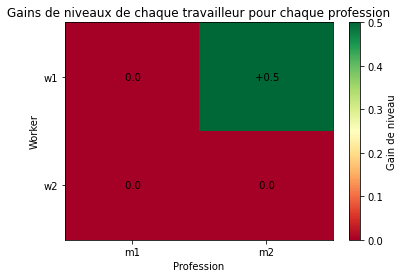

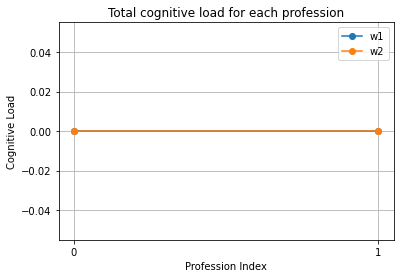

cognitive_load_total_per_worker=
[0. 0.]


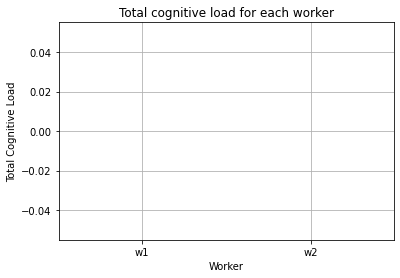

In [43]:
print("======= VISUALIZATION ========")
resume_levels_workers(s_2, instance_2, verbose=True)
plot_cognitive_load_total(s_2, instance_2)
bars_cognitive_load_total(s_2, instance_2, verbose=True)

- Worker qui a fait sans niveau requiq a augmenter son level comme apprenant

## Pas de travailleur qualifié pour finaliser le job 1 
### Refusant qu'un travailleur puisse faire une tâche seul sans niveau requis

In [ ]:
print("======== CONFIG ========")
constraints_config = {"constrained_makespan": True,
                      "job_with_no_skills": False }

# de base : 
# - worker de base 
# - pas le droit de fair une opération sans level requis



print("======== SOLVE ========")
model_2 = Model(instance_2)
s_2 = model_2.solve(objective="lexicographic", weight=[0, 0, 0], priority=[2, 1, 0], constraints_config=constraints_config, verbose=False)